# Suraksha360 — AI Safety Score Model Training

**Data disclosure:** this notebook trains on a *synthetic* dataset (`generate_dataset.py`),
built from realistic, domain-informed rules (time of day, route deviation, nearby
safe zones, community reports, etc.) with random noise layered on top to simulate
real-world unpredictability. This is a standard way to bootstrap a first model
before a real labeled incident dataset is available, and is disclosed here rather
than presented as real historical data.

Two models are trained:
1. **RandomForestRegressor** — predicts the continuous 0-100 Safety Score. Used to
   validate the approach and inspect feature importances.
2. **LogisticRegression** — classifies a journey as high-risk or not. Small enough
   that its *exact learned coefficients* are re-implemented directly in the
   production TypeScript app (`src/lib/risk-engine.ts`), so this is a real trained
   model powering the live product, not just a notebook exercise.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("journeys_synthetic.csv")
df.head()

,hour,distance_km,route_deviation_m,unexpected_stop_s,nearby_safe_zone_count,nearby_police_or_hospital,community_reports_nearby,is_weekend,safety_score,high_risk
0,2,6.69,77.4,53.8,0,0,2,0,47.5,1
1,18,4.87,5.7,33.4,1,0,2,0,87.8,0
2,15,2.19,84.2,38.2,3,0,2,0,78.9,0
3,10,6.04,0.6,9.6,3,0,0,0,86.8,0
4,10,0.95,0.3,20.1,0,0,0,1,91.9,0


## Exploratory look at the training data

In [2]:
df.describe()

,hour,distance_km,route_deviation_m,unexpected_stop_s,nearby_safe_zone_count,nearby_police_or_hospital,community_reports_nearby,is_weekend,safety_score,high_risk
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,11.475333,4.117192,60.731200,19.912150,2.215667,0.448833,0.783833,0.272500,81.994100,0.220000
std,6.926499,2.210797,60.590691,19.912687,1.491820,0.497417,0.885194,0.445283,17.775996,0.414281
min,0.000000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.300000,0.000000
25%,5.000000,2.210000,17.400000,5.700000,1.000000,0.000000,0.000000,0.000000,69.700000,0.000000
50%,11.000000,4.130000,41.900000,13.900000,2.000000,0.000000,1.000000,0.000000,86.400000,0.000000
75%,18.000000,6.010000,84.325000,27.700000,3.000000,1.000000,1.000000,1.000000,99.900000,0.000000
max,23.000000,8.000000,573.700000,187.700000,9.000000,1.000000,5.000000,1.000000,100.000000,1.000000


High-risk journey rate: 0.22


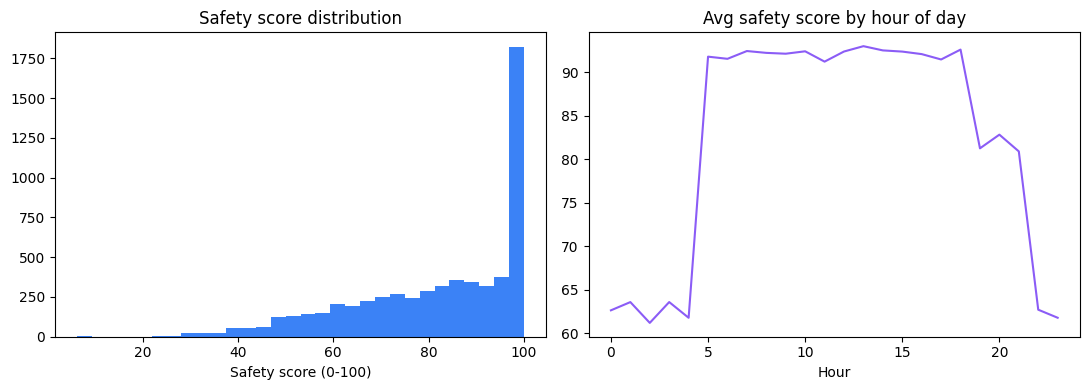

In [3]:
print("High-risk journey rate:", df["high_risk"].mean().round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["safety_score"], bins=30, color="#3B82F6")
axes[0].set_title("Safety score distribution")
axes[0].set_xlabel("Safety score (0-100)")
df.groupby("hour")["safety_score"].mean().plot(ax=axes[1], color="#8B5CF6")
axes[1].set_title("Avg safety score by hour of day")
axes[1].set_xlabel("Hour")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=130)
plt.show()

## Train / test split

In [4]:
FEATURES = [
    "hour", "distance_km", "route_deviation_m", "unexpected_stop_s",
    "nearby_safe_zone_count", "nearby_police_or_hospital",
    "community_reports_nearby", "is_weekend",
]

X = df[FEATURES]
y_reg = df["safety_score"]
y_clf = df["high_risk"]

X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")

Train size: 4800  Test size: 1200


## Model 1 — RandomForestRegressor (continuous Safety Score)

In [5]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, yreg_train)
pred = rf.predict(X_test)

mae = mean_absolute_error(yreg_test, pred)
r2 = r2_score(yreg_test, pred)
print(f"MAE: {mae:.2f} points (out of 100)")
print(f"R^2: {r2:.3f}")

MAE: 6.19 points (out of 100)
R^2: 0.794


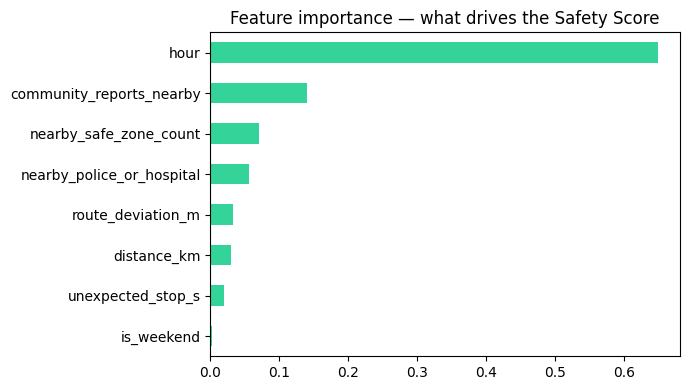

In [6]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", color="#34D399", figsize=(7, 4))
plt.title("Feature importance — what drives the Safety Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130)
plt.show()

**Reading this**: hour-of-day dominates (matches real-world safety research —
time of travel is consistently the strongest predictor of personal safety risk),
followed by nearby community reports and safe-zone availability. This lines up
with domain expectations, which is a good sanity check for a first model.

## Model 2 — LogisticRegression (High-Risk Classifier)

Standardized features, `class_weight='balanced'` — in a safety application, missing a real high-risk journey (false negative) is worse than an extra caution shown for a safe one (false positive), so recall is prioritized over precision.

In [7]:
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(Xs_train, yclf_train)
clf_pred = logreg.predict(Xs_test)

acc = accuracy_score(yclf_test, clf_pred)
prec = precision_score(yclf_test, clf_pred)
rec = recall_score(yclf_test, clf_pred)
f1 = f1_score(yclf_test, clf_pred)
cm = confusion_matrix(yclf_test, clf_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")
print("Confusion matrix:\n", cm)

Accuracy:  0.693
Precision: 0.390
Recall:    0.705
F1 score:  0.502
Confusion matrix:
 [[645 291]
 [ 78 186]]


In [8]:
import json
print("Learned coefficients (standardized feature space):")
for name, coef in zip(FEATURES, logreg.coef_[0]):
    print(f"  {name:28s} {coef:+.4f}")
print(f"  {'intercept':28s} {logreg.intercept_[0]:+.4f}")

Learned coefficients (standardized feature space):
  hour                         -0.3574
  distance_km                  +0.1803
  route_deviation_m            +0.1849
  unexpected_stop_s            +0.1224
  nearby_safe_zone_count       -0.5269
  nearby_police_or_hospital    -0.4401
  community_reports_nearby     +0.6546
  is_weekend                   +0.1094
  intercept                    -0.2504


## Exporting for production

The trained logistic regression's coefficients + the scaler's mean/scale are
exported to `model_export.json`. Because logistic regression is just a weighted
sum through a sigmoid, the exact trained model is re-implemented as a small,
exact formula in `src/lib/risk-engine.ts` in the live Next.js app — the website
runs the real trained weights, not an approximation.

In [9]:
joblib_paths = []
import joblib
joblib.dump(rf, "safety_score_rf.pkl")
joblib.dump(logreg, "high_risk_logreg.pkl")
joblib.dump(scaler, "high_risk_scaler.pkl")
print("Saved model files: safety_score_rf.pkl, high_risk_logreg.pkl, high_risk_scaler.pkl")

Saved model files: safety_score_rf.pkl, high_risk_logreg.pkl, high_risk_scaler.pkl
